<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week4_decision_trees_original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Decision Trees + Bias-Variance Tradeoff
**EMA Crossover ML Project | 10-Week Curriculum**
**Date:** June 30, 2026

---

### How this notebook is built, and why



This version splits into two modes:

**Part A (Setup) — fully working code, heavily commented.** This is Week 1-3 infrastructure: DB connection, merge, signal scoring, your two classification targets, the feature engineering pipeline, and the CV functions. You already wrote and debugged all of this. Re-deriving it from scratch this week wouldn't teach you anything about Decision Trees — it would just be busywork. So it runs as-is, but every block has comments explaining *why* it's written the way it is, not just *what* it does, so if you ever need to modify it you understand the reasoning.

**Parts B–G (the actual Week 4 content) — concept explained, code scaffolded, you write the logic.** Every code cell has imports and variable names set up, a comment header describing what the cell needs to do, and `# TODO:` markers where you write the real logic. Nothing here is filled in for you. If you get stuck, the markdown above each cell explains the concept in enough depth that you should be able to work out the code from first principles — that's the point.

**One housekeeping note carried over from the last version:** Week 3's AUC computation had a real bug — `roc_auc_score(..., multi_class='ovr')` was called on a binary target, which throws on every fold and was silently caught, faking every AUC as `0.5000`. Part A's CV functions use the correct binary pattern (`predict_proba(X)[:, 1]` → plain `roc_auc_score`) and include a verification cell so you can confirm AUC is actually working before you build anything on top of it.

---
# PART A — Setup (working code, heavily commented)

This is carried-forward infrastructure from Weeks 1–3. It runs as one block. Read the comments if you want to understand the reasoning behind any line — but you don't need to write or modify this section this week.

In [ ]:
# Colab doesn't ship with the supabase client or statsmodels by default,
# so install them fresh each session. The -q flag keeps the install log quiet.
!pip install -q supabase scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.7 MB/s eta 0:00:00


In [ ]:
# ============================================================
# PART A.1 — IMPORTS
# ============================================================
# pandas/numpy: the core data manipulation layer everything else sits on top of.
# matplotlib/seaborn: plotting. seaborn just gives matplotlib nicer default styling.
# warnings.filterwarnings('ignore'): sklearn and pandas throw a lot of harmless
#   FutureWarning/DeprecationWarning noise — silenced so real output isn't buried.
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from itertools import product   # used later for grid search combinations
warnings.filterwarnings('ignore')

# supabase + colab userdata: this is how we read the two database credential
# sets without ever hardcoding a key in the notebook itself.
from supabase import create_client
from google.colab import userdata

# sklearn imports, grouped by what they're for:
from sklearn.linear_model import LogisticRegression           # this week's baseline model
from sklearn.tree import DecisionTreeClassifier, plot_tree     # this week's actual subject
from sklearn.ensemble import BaggingClassifier                 # Friday's variance-reduction preview
from sklearn.preprocessing import StandardScaler                # needed for LogReg, NOT for trees
from sklearn.model_selection import TimeSeriesSplit              # the correct CV splitter for time-ordered data
from sklearn.base import clone                                   # makes a fresh, unfitted copy of a model per fold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option('display.max_columns', None)   # don't truncate wide dataframes when printing
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Environment ready')

Environment ready


## A.2 — Connect to both databases

Your project splits data across two Supabase projects: raw signal features in one, post-signal outcomes (MFE/MAE/profit) in the other. Both client objects just need credentials pulled from Colab's secrets manager — `userdata.get()` reads them without ever printing or hardcoding the actual key.

In [ ]:
main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
analytics_client = create_client(userdata.get('ANALYTICS_SUPABASE_URL'), userdata.get('ANALYTICS_SUPABASE_KEY'))
print('Both databases connected')

Both databases connected


## A.3 — Fetch + merge

We filter to `status == 'analyzed'` because unanalyzed signals don't have outcome data yet — including them would just be rows full of NaN. Datetimes are parsed with `utc=True` so every timestamp comparison later is unambiguous (no silent local-timezone bugs). The merge is an **inner join** on `(symbol, checked_at_utc)` — a signal only survives the merge if both its raw features AND its outcome exist, which is exactly what we want for supervised learning.

One thing to watch for, which tripped up Week 3: keep exactly **one** merged dataframe. Building two parallel ones (`df` and `df_all`) from duplicate fetches is easy to do by accident and risks training on the wrong one without noticing.

In [ ]:
# Pull every analyzed signal from the main DB.
df_main = pd.DataFrame(main_client.table('signals').select('*').eq('status', 'analyzed').execute().data)

# Parse all timestamp columns as timezone-aware UTC. errors='coerce' means any
# unparseable value becomes NaT instead of crashing the whole pipeline.
for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

# Sort chronologically now — this matters a lot later, because TimeSeriesSplit
# assumes row order IS time order. If this sort is skipped, walk-forward CV
# silently becomes meaningless.
df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)

# Same pattern for the analytics (outcomes) table.
df_analytics = pd.DataFrame(analytics_client.table('crossover_analytics').select('*').execute().data)
for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')
df_analytics = df_analytics.sort_values('crossover_utc').reset_index(drop=True)

# The two tables use different column names for the same timestamp concept
# (crossover_utc vs checked_at_utc) — rename before merging so the join key matches.
# how='inner': only keep rows that exist in BOTH tables.
df = pd.merge(df_main, df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'}),
              how='inner', on=['checked_at_utc', 'symbol'])

print(f'Merged: {len(df):,} rows | {df.shape[1]} columns')
print(df['symbol'].value_counts())

Merged: 64,673 rows | 60 columns
symbol
BTCUSDT     13869
XRPUSDT     13817
ETHUSDT     13516
DOGEUSDT    12213
SOLUSDT     11258
Name: count, dtype: int64


## A.4 — Signal quality scoring + classification targets

The four-track scoring system (T1–T4) is locked from Week 1 and encodes domain knowledge about what makes a trade "good" — reward-to-risk ratio, how fast profit was reached, whether the trade fought the higher-timeframe trend. It doesn't change week to week, so it's not something to re-derive.

The two **classification targets** below are what actually changed mid-Week-3, and they're what every model this week predicts:

- **`class_target_1`** rewards trades where profit dominated *efficiently* over drawdown: `(mfe/(mfe+mae)) * (mfe-mae) > 0.4`. This is a harder bar to clear — it punishes trades that were profitable but ground through a lot of adverse movement first.
- **`class_target_2`** is a simple `mfe_percent > 1` threshold — did the trade ever reach 1% unrealized profit, full stop.

Both are trained on in parallel all week. That's deliberate — comparing how a tree behaves on a strict target vs. a loose one is itself part of what you're learning.

In [48]:
# --- Signal quality scoring (Week 1, locked) ---

def get_time_decay_score(c):
    # Trades that hit their peak profit FAST score higher than ones that
    # took hundreds of candles to get there — speed matters for capital efficiency.
    if c <= 20: return 1.0
    elif c <= 100: return np.exp(-3.5 * (c-20)/80)
    elif c <= 400: return np.exp(-3.5) * np.exp(-4 * (c-100)/300)
    else: return 0.0

def time_cutoff(c):
    return 1.0 if c <= 20 else (0.5 if c <= 40 else 0)

def calculate_four_target_scores(row):
    # LONG and SHORT trades need their "profit" and "risk" sides swapped —
    # for a LONG, profit is upside move; for a SHORT, profit is downside move.
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        ctp, ctmp = int(row['candles_to_max_price']), int(row['candles_to_min_price'])
        is_btc, is_1d, is_4h = bool(row['btc_trend_bias']), bool(row['htf_1d_bias']), bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        ctp, ctmp = int(row['candles_to_min_price']), int(row['candles_to_max_price'])
        is_btc, is_1d, is_4h = not bool(row['btc_trend_bias']), not bool(row['htf_1d_bias']), not bool(row['htf_4h_bias'])

    # Guard against division by zero when risk (r) is ~0
    r_safe = 0.01 if r <= 0 else r
    rr = p / r_safe   # realised reward:risk ratio
    base = round(min(5.0, rr) + 5.0 * get_time_decay_score(ctp), 2)
    t1 = base   # T1: pure continuous score, no hard gates

    # T2: same as T1 but trades that hit max pain before max profit (and lost
    # more than they gained) get heavily discounted instead of zeroed out
    if ctmp < ctp and r >= p: t2 = round(base * 0.2, 2)
    elif r < 0.25: t2 = round(base * 0.1, 2)
    else: t2 = base

    # T3: T1 base minus penalties for fighting the trend / low volume / drawdown-first
    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc: pen -= 0.5
    if not is_1d:  pen -= 1.0
    if not is_4h:  pen -= 1.2
    if ctmp < ctp and r > 0.75*p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    # T4: original hard-gate version (kept only for historical comparison)
    if r < 0.25 or (ctmp < ctp and r >= p): t4 = 0.0
    else:
        rr_p = 5.0 if rr>=4 else (rr if rr>=1.5 else ((rr**7)/(1.5**6) if rr>=1.0 else 0.0))
        t4 = round(5.0*time_cutoff(ctp) + rr_p, 2) if rr_p > 0 else 0.0
    return t1, t2, t3, t4

def optimal_entry_candles(row):
    # How many 15-min candles after the crossover was the BEST entry point?
    # 0 = the crossover candle itself was already optimal.
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']): return 0.0
        return float((row['optimal_entry_utc'] - row['checked_at_utc']).total_seconds() / 900)  # 900s = 15min
    except: return 0.0

target_cols = ['T1_Pure_Continuous','T2_Soft_Floor','T3_Assumption_Penalty','T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)   # row-wise min of T1-T3 = must pass ALL three
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

# --- Classification targets (Week 3, what we actually predict this week) ---
mae_abs, mfe_abs = df['mae_percent'].abs(), df['mfe_percent'].abs()

# class_target_1: efficiency-weighted net profit. The (mfe/(mfe+mae)) term is
# a 0-1 "how much of the total excursion was profit vs drawdown" ratio;
# multiplying by (mfe-mae) means a trade also needs positive net profit.
df['target_b']       = (mfe_abs / (mfe_abs + mae_abs + 1e-8)) * (mfe_abs - mae_abs)
df['class_target_1'] = (df['target_b'] > 0.4).astype(int)

# class_target_2: simple, permissive — did unrealized profit ever cross 1%?
df['class_target_2'] = (df['mfe_percent'] > 1).astype(int)
df['class_target_3'] = (df['mfe_percent'] < -0.5).astype(int)

print('Quality columns + targets applied')
print(f'CT1 +%: LONG {df[df["signal_x"]=="LONG"]["class_target_1"].mean()*100:.1f}%  SHORT {df[df["signal_x"]=="SHORT"]["class_target_1"].mean()*100:.1f}%')
print(f'CT2 +%: LONG {df[df["signal_x"]=="LONG"]["class_target_2"].mean()*100:.1f}%  SHORT {df[df["signal_x"]=="SHORT"]["class_target_2"].mean()*100:.1f}%')

Quality columns + targets applied
CT1 +%: LONG 37.1%  SHORT 38.9%
CT2 +%: LONG 38.1%  SHORT 40.0%


## A.5 — Feature engineering pipeline (Week 3 logic, rebuilt on 65k+)

Every block below creates one *category* of engineered feature. The comment above each block explains the trading logic behind why that category might help a model — read these even though you're not writing this code, since the same reasoning will matter when you interpret which features the Decision Tree picks as important in Part D.

**Why Decision Trees don't need scaling, but this pipeline still produces some scaled-looking ratios anyway:** a tree picks a threshold like `feature <= 0.73` at each split — multiplying every value in a column by 1000 doesn't change which rows fall on which side of that threshold, only the number written in the split. So scaling is irrelevant *for trees specifically*. It still matters for the Logistic Regression baseline in Part A.7, which is why both a scaled (`cv_with_scaling`) and unscaled (`cv_no_scaling`) CV function exist below.

In [ ]:
def safe_ratio(num, den):
    # Avoid div-by-zero / inf blowing up downstream models — replace bad
    # values with NaN first, then fill with a neutral 0.0.
    return (num / den.replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0.0)

# --- Interaction features: does combining two signals reveal more than either alone? ---
# e.g. ADX (trend strength) ALONE doesn't tell you if volume backs the move —
# multiplying them together creates a feature that's high only when BOTH are high.
df['FE_adx_x_volume']        = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)
df['FE_macd_x_volume']       = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)
df['FE_ema_sep_x_adx']       = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)
df['FE_rsi_x_htf4h']         = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d']         = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d']       = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_adx_x_atr_pct']       = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['price'].astype(float))
df['FE_rsi_delta_x_vol']     = df['rsi_ltf'].astype(float).diff(2).fillna(0) * df['volume_ratio'].astype(float)
df['FE_exhaustion_risk']      = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

# --- Ratio features: relative comparisons normalize across different price/volatility regimes ---
df['FE_ema_ratio']            = safe_ratio(df['ema_fast_ltf'].astype(float), df['ema_slow_ltf'].astype(float))
df['FE_price_to_bb']          = safe_ratio(df['atr_pct'].astype(float), df['bb_width_ltf'].astype(float))
df['FE_adx_4h_ratio']         = safe_ratio(df['adx_ltf'].astype(float), df['adx_4h'].astype(float))
df['FE_vol_efficiency_ratio'] = safe_ratio(df['volume_ratio'].astype(float), df['atr_pct'].astype(float))
df['FE_rsi_mtf_ratio']        = safe_ratio(df['rsi_ltf'].astype(float), df['rsi_4h'].astype(float))
df['FE_spread_to_atr_ratio']  = safe_ratio((df['price'].astype(float)-df['ema_fast_ltf'].astype(float)), df['atr_ltf'].astype(float))

# --- Boolean / regime flags: hard yes-no conditions, often what a tree's first split looks like ---
df['FE_adx_trending']        = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending']     = (df['adx_4h'].astype(float) > 25.0).astype(int)
df['FE_rsi_overbought']      = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold']        = (df['rsi_ltf'].astype(float) < 35.0).astype(int)
df['FE_rsi_4h_bull']         = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume']         = (df['volume_ratio'].astype(float) > 1.5).astype(int)
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int)==1) & (df['htf_1d_bias'].astype(int)==1)).astype(int)
strict_s   = (df['htf_4h_bias'].astype(int)==-1) & (df['htf_1d_bias'].astype(int)==-1)
fallback_s = (df['htf_4h_bias'].astype(int)==-1) & (df['htf_1d_bias'].astype(int)<=0)
df['FE_full_htf_align_short'] = np.where(strict_s.any(), strict_s.astype(int), fallback_s.astype(int))
df['FE_btc_volume_align']    = ((df['btc_trend_bias'].astype(int)==1) & (df['volume_ratio'].astype(float)>1.0)).astype(int)
df['FE_bb_squeeze_regime']   = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['price'].astype(float) > df['price'].astype(float).shift(3)) &
    (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)

# --- Market session features: crypto liquidity/volatility differs by which exchanges are open ---
df['FE_session_asia']    = df['hour_of_day'].isin([23,0,1,2,3,4,5,6,7,8]).astype(int)
df['FE_session_london']  = df['hour_of_day'].isin([7,8,9,10,11,12,13,14,15,16]).astype(int)
df['FE_session_ny']      = df['hour_of_day'].isin([13,14,15,16,17,18,19,20,21]).astype(int)
df['FE_session_overlap'] = df['hour_of_day'].isin([13,14,15]).astype(int)  # London/NY overlap = highest liquidity
is_pg_wknd = (df['day_of_week']==6)|(df['day_of_week']==0)   # Postgres convention: Sunday=0
is_pd_wknd = (df['day_of_week']==5)|(df['day_of_week']==6)   # pandas convention: Saturday=5
df['FE_weekend'] = np.where((df['day_of_week']==0).sum() > (df['day_of_week']==5).sum()*1.5,
                             is_pg_wknd.astype(int), is_pd_wknd.astype(int))
df['FE_overlap_x_volume'] = df['FE_session_overlap'] * df['volume_ratio'].astype(float)
df['FE_asia_x_volume']    = df['FE_session_asia']    * df['volume_ratio'].astype(float)

# --- Regime bins: convert continuous values into discrete buckets ---
# Trees can already find their own thresholds, so these bins aren't strictly
# necessary for a tree the way they help a linear model — but they're cheap
# to keep for comparison and don't hurt.
df['FE_adx_regime'] = pd.cut(df['adx_ltf'].astype(float), bins=[-np.inf,20.0,35.0,np.inf], labels=[0,1,2]).astype(int)
df['FE_rsi_zone']   = pd.cut(df['rsi_ltf'].astype(float), bins=[-np.inf,30.0,45.0,55.0,70.0,np.inf], labels=[0,1,2,3,4]).astype(int)
df['FE_optimum_entry_bin'] = pd.cut(df['Optimum_entry'].astype(float), bins=[-np.inf,0.5,5.0,20.0,np.inf], labels=[0,1,2,3]).astype(int)

# --- Lag features: MUST sort by (symbol, time) first, or shift() mixes coins together ---
df = df.sort_values(['symbol','checked_at_utc']).reset_index(drop=True)
signal_map = {'LONG':1,'SHORT':-1}
sig_num = df['signal_x'].map(signal_map).fillna(0).astype(int)
df['FE_prev_signal_dir'] = df.groupby('symbol')['signal_x'].shift(1).map(signal_map).fillna(0).astype(int)
df['FE_prev_t3_score']   = df.groupby('symbol')['T3_Assumption_Penalty'].shift(1).fillna(0.0)

def streak(s):
    # Counts consecutive repeats of the same value — e.g. "3 LONG signals in a row"
    c = s.ne(s.shift(1)).cumsum()
    return s.groupby(c).cumcount() + 1

df['FE_same_dir_streak']    = df.groupby('symbol')['signal_x'].transform(streak).fillna(0).astype(int)
df['FE_signal_gap_candles'] = df['signal_gap_hours'].astype(float) * 4.0   # 4 candles per hour at 15min
df['FE_prev_bb_squeeze']    = df.groupby('symbol')['FE_bb_squeeze_regime'].shift(1).fillna(0).astype(int)
raw_dc = sig_num != df['FE_prev_signal_dir']
raw_dc.loc[df.groupby('symbol').head(1).index] = False  # first row per symbol has no "previous" to compare
df['FE_dir_changed'] = raw_dc.astype(int)
prev_gap = df.groupby('symbol')['signal_gap_hours'].shift(1).replace(0,np.nan)
df['FE_prev_signal_gap_decay'] = (df['signal_gap_hours'].astype(float)/prev_gap).replace([np.inf,-np.inf],np.nan).fillna(1.0)

# One-hot encode the regime bins (needed for LogReg's coefficients to make
# sense per-category; trees can use the raw ordinal column directly)
df['_tmp_adx'] = df['FE_adx_regime']; df['_tmp_rsi'] = df['FE_rsi_zone']
df = pd.get_dummies(df, columns=['_tmp_adx','_tmp_rsi'], prefix=['DUM_adx','DUM_rsi'], drop_first=True, dtype=int)

FE_FEATURES = [c for c in df.columns if c.startswith('FE_') or c.startswith('DUM_')]
print(f'Engineered features: {len(FE_FEATURES)}')

Engineered features: 49


## A.6 — Feature sets

Three named groups, used throughout the notebook so you can compare a tree's behavior on raw features vs engineered features vs a hand-selected subset:

- `FEATURES_ALL` — the original 33 technical features from the database
- `FEATURES_COMBINED` — raw + everything engineered above
- `FEATURES_SELECTED_LONG`/`SHORT` — your Week 3 wrapper-selected subsets (pasted from your actual notebook output, not placeholders)

One known issue carried over: `WRAPPER_FIRST_FINAL_LONG` references `FE_mfe_mae_ratio_lag`, a column that's never actually created anywhere above. It gets filtered out automatically with a printed warning rather than crashing.

In [ ]:
FEATURES_ALL = [f for f in [
    'ema_fast_ltf','ema_slow_ltf','ema_fast_slope','ema_slow_slope','ema_separation','price_above_both_emas',
    'crossover_candle_strength','adx_ltf','adx_slope','adx_4h','macd_histogram_ltf','macd_histogram_4h',
    'htf_4h_bias','htf_1d_bias','ema_separation_4h','rsi_4h','rsi_ltf','roc_ltf','atr_ltf','atr_pct',
    'bb_width_ltf','price_to_atr','volume_ratio','volume_trend','crossover_volume_ratio','fear_greed_index',
    'btc_trend_bias','hour_of_day','day_of_week','swing_high','swing_low','atr_stop_distance','signal_gap_hours'
] if f in df.columns]
FEATURES_COMBINED = list(FEATURES_ALL) + [f for f in FE_FEATURES if f not in FEATURES_ALL]

WRAPPER_FIRST_FINAL_LONG = [
    'rsi_4h', 'FE_spread_to_atr_ratio', 'FE_optimum_entry_bin', 'ema_separation',
    'atr_pct', 'FE_rsi4h_x_htf1d', 'price_to_atr', 'FE_btc_volume_align', 'FE_prev_t3_score',
    'adx_slope', 'hour_of_day', 'FE_rsi_overbought', 'FE_adx_4h_trending', 'atr_stop_distance',
    'DUM_rsi_4', 'day_of_week', 'macd_histogram_4h', 'FE_asia_x_volume', 'FE_adx_trending',
    'crossover_candle_strength', 'FE_same_dir_streak'
]
WRAPPER_FIRST_FINAL_SHORT = [
    'rsi_4h', 'FE_spread_to_atr_ratio', 'price_to_atr',
    'FE_optimum_entry_bin', 'FE_rsi4h_x_htf1d', 'ema_separation',
    'FE_adx_x_atr_pct', 'FE_prev_t3_score', 'FE_session_overlap',
    'adx_4h', 'FE_btc_volume_align', 'FE_asia_x_volume', 'FE_rsi_delta_x_vol',
    'FE_prev_bb_squeeze', 'macd_histogram_ltf', 'FE_adx_trending', 'FE_session_london',
    'FE_high_volume', 'FE_session_ny', 'volume_trend', 'macd_histogram_4h', 'hour_of_day', 'FE_rsi_oversold'
]
missing_long  = [f for f in WRAPPER_FIRST_FINAL_LONG  if f not in df.columns]
missing_short = [f for f in WRAPPER_FIRST_FINAL_SHORT if f not in df.columns]
FEATURES_SELECTED_LONG  = [f for f in WRAPPER_FIRST_FINAL_LONG  if f in df.columns]
FEATURES_SELECTED_SHORT = [f for f in WRAPPER_FIRST_FINAL_SHORT if f in df.columns]

# Split by trade direction — LONG and SHORT t|rades have different feature
# distributions (e.g. htf_bias signs flip), so they're modeled separately.
df_long  = df[df['signal_x']=='LONG'].sort_values('checked_at_utc').reset_index(drop=True)
df_short = df[df['signal_x']=='SHORT'].sort_values('checked_at_utc').reset_index(drop=True)

print(f'FEATURES_ALL: {len(FEATURES_ALL)} | COMBINED: {len(FEATURES_COMBINED)} | SELECTED_LONG: {len(FEATURES_SELECTED_LONG)} | SELECTED_SHORT: {len(FEATURES_SELECTED_SHORT)}')
print(f'df_long: {len(df_long):,} | df_short: {len(df_short):,}')
if missing_long:  print(f'WARNING dropped undefined LONG feature(s):  {missing_long}')
if missing_short: print(f'WARNING dropped undefined SHORT feature(s): {missing_short}')

FEATURES_ALL: 33 | COMBINED: 82 | SELECTED_LONG: 21 | SELECTED_SHORT: 23
df_long: 32,322 | df_short: 32,351


so i changed the wrapped features i didnt change the feature selection process and all of my thressholds still remain

## A.7 — Walk-forward CV functions

**Why not regular k-fold CV?** Standard k-fold shuffles rows randomly into folds. For time-series trading data, that means a model could train on March data and get tested on January data — predicting the past from the future. `TimeSeriesSplit` instead always trains on an earlier chronological block and tests on a later one, which is the only way to honestly simulate "would this have worked if I'd deployed it."

**Two versions, for two different model types:**
- `cv_with_scaling()` — fits a `StandardScaler` *inside* each fold (on training data only, then applies it to test data). Necessary for Logistic Regression, which is sensitive to feature magnitude.
- `cv_no_scaling()` — skips the scaler entirely. Decision Trees split on `feature <= threshold` — multiplying a column by 1000 doesn't change which side of that threshold any row falls on, so scaling is wasted computation for trees.

**The AUC bug, explained so you don't reintroduce it:** `roc_auc_score(y_true, y_score)` for a *binary* target wants `y_score` to be the probability of the positive class — a single column, `predict_proba(X)[:, 1]`. An earlier version of this code called it with `multi_class='ovr'`, which is a setting for problems with 3+ classes and expects a completely different probability shape. That mismatch threw an exception on every single fold. The code that caught it (`except Exception: scores['auc'].append(0.50)`) papered over the crash with a fake constant instead of surfacing the error — which is why every AUC in an earlier table read exactly `0.5000`. The fix is just: don't pass `multi_class` for a binary target, and never silently swallow an exception on a metric you're about to report as real.

In [ ]:
def cv_with_scaling(model, df_subset, feature_cols, target_col, n_splits=5, gap=0):
    """Walk-forward CV with StandardScaler fit per fold. Use for LogReg."""
    df_c = df_subset[feature_cols+[target_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    X, y = df_c[feature_cols].values, df_c[target_col].values
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    scores = {k:[] for k in ['accuracy','precision','recall','f1','auc']}
    for tr, te in tscv.split(X):
        Xtr,Xte,ytr,yte = X[tr],X[te],y[tr],y[te]
        # Skip a fold if either side ends up with only one class present —
        # precision/recall/AUC are undefined (or misleading) in that case.
        if len(np.unique(ytr))<2 or len(np.unique(yte))<2: continue
        sc = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)   # fit on TRAIN only — no leakage
        m = clone(model); m.fit(Xtr_s,ytr)
        yp, yprob = m.predict(Xte_s), m.predict_proba(Xte_s)[:, 1]   # [:, 1] = probability of class "1"
        scores['accuracy'].append(accuracy_score(yte,yp))
        scores['precision'].append(precision_score(yte,yp,zero_division=0))
        scores['recall'].append(recall_score(yte,yp,zero_division=0))
        scores['f1'].append(f1_score(yte,yp,zero_division=0))
        scores['auc'].append(roc_auc_score(yte,yprob))   # plain binary call — no multi_class argument
    return {k:(np.mean(v),np.std(v)) if v else (0.0,0.0) for k,v in scores.items()}


def cv_no_scaling(model, df_subset, feature_cols, target_col, n_splits=5, gap=0):
    """Same as above, no scaling. Use for Decision Trees / Random Forests."""
    df_c = df_subset[feature_cols+[target_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    X, y = df_c[feature_cols].values, df_c[target_col].values
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    scores = {k:[] for k in ['accuracy','precision','recall','f1','auc']}
    for tr, te in tscv.split(X):
        Xtr,Xte,ytr,yte = X[tr],X[te],y[tr],y[te]
        if len(np.unique(ytr))<2 or len(np.unique(yte))<2: continue
        m = clone(model); m.fit(Xtr,ytr)
        yp, yprob = m.predict(Xte), m.predict_proba(Xte)[:, 1]
        scores['accuracy'].append(accuracy_score(yte,yp))
        scores['precision'].append(precision_score(yte,yp,zero_division=0))
        scores['recall'].append(recall_score(yte,yp,zero_division=0))
        scores['f1'].append(f1_score(yte,yp,zero_division=0))
        scores['auc'].append(roc_auc_score(yte,yprob))
    return {k:(np.mean(v),np.std(v)) if v else (0.0,0.0) for k,v in scores.items()}


def print_cv(res, name='Model'):
    print(f'\n=== {name} ===')
    for metric,(mean,std) in res.items(): print(f'  {metric:<12}: {mean:.4f} +/- {std:.4f}')

print('cv_with_scaling, cv_no_scaling defined')

cv_with_scaling, cv_no_scaling defined


## A.8 — Logistic Regression baseline

This is the number every Decision Tree result this week has to beat. If a tree can't outperform this simple linear baseline, the extra complexity (and overfitting risk) isn't earning its keep.

In [49]:
lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)
baseline_results = {}
for direction, df_dir in [('LONG',df_long),('SHORT',df_short)]:
    feats = [f for f in FEATURES_COMBINED if f in df_dir.columns]
    for target in ['class_target_1','class_target_2','class_target_3']:
        res = cv_with_scaling(lr, df_dir, feats, target, n_splits=10)
        baseline_results[f'{direction}_{target}'] = res
        print_cv(res, f'LogReg baseline {direction} {target} (Combined, 65k+)')


=== LogReg baseline LONG class_target_1 (Combined, 65k+) ===
  accuracy    : 0.6476 +/- 0.0273
  precision   : 0.5205 +/- 0.0191
  recall      : 0.5990 +/- 0.0863
  f1          : 0.5553 +/- 0.0456
  auc         : 0.6848 +/- 0.0183

=== LogReg baseline LONG class_target_2 (Combined, 65k+) ===
  accuracy    : 0.7095 +/- 0.0253
  precision   : 0.6079 +/- 0.0332
  recall      : 0.6285 +/- 0.1004
  f1          : 0.6161 +/- 0.0636
  auc         : 0.7545 +/- 0.0109

=== LogReg baseline LONG class_target_3 (Combined, 65k+) ===
  accuracy    : 0.8482 +/- 0.0312
  precision   : 0.7804 +/- 0.0393
  recall      : 0.8036 +/- 0.0540
  f1          : 0.7906 +/- 0.0356
  auc         : 0.9219 +/- 0.0177

=== LogReg baseline SHORT class_target_1 (Combined, 65k+) ===
  accuracy    : 0.6505 +/- 0.0244
  precision   : 0.5454 +/- 0.0227
  recall      : 0.6204 +/- 0.0668
  f1          : 0.5793 +/- 0.0379
  auc         : 0.6970 +/- 0.0219

=== LogReg baseline SHORT class_target_2 (Combined, 65k+) ===
  accura

---
# PART B — Information Theory (Monday)

### Concept: how does a Decision Tree decide where to split?

At every node, a tree tries every feature and every possible threshold, and picks whichever single split makes the two resulting groups **most pure** — meaning each group leans as heavily as possible toward one class. "Purity" needs a number to compare splits against each other, and there are two standard ways to measure it.

**Entropy** (from information theory) measures how "surprising" a random draw from a group is:
$$H(y) = -\sum_i p_i \log_2(p_i)$$
If a group is 100% one class, there's no surprise in a random draw — entropy is 0. If a group is a perfect 50/50 mix, a random draw is maximally uncertain — entropy is 1 (its maximum for binary data).

**Information Gain** is how much entropy *drops* after a split, weighted by how big each resulting group is:
$$IG = H(parent) - \frac{n_{left}}{n} H(left) - \frac{n_{right}}{n} H(right)$$
A tree picks the split with the highest information gain at every node — the split that reduces uncertainty the most.

**Gini Impurity** is sklearn's default alternative, and asks a slightly different question — "if I randomly label a point according to the group's class proportions, how often would I be wrong?":
$$Gini(y) = 1 - \sum_i p_i^2$$
It's cheaper to compute (no logarithm) and in practice produces nearly identical trees to entropy.

### Your task

Implement `entropy()`, `gini()`, and `information_gain()` from scratch using only `numpy`. Then use them to manually evaluate a few candidate splits on your real `class_target_1` data and see which one a tree would actually pick.

In [ ]:
# ============================================================
# TODO: Implement entropy(y) -> float
# ============================================================
# y is a 1D array/Series of 0s and 1s.
# Steps:
#   1. Convert y to a numpy array, get n = len(y). If n == 0, return 0.0.
#   2. Compute p = (fraction of y that equals 1), q = 1 - p
#   3. Entropy = -(p * log2(p)) - (q * log2(q))
#      WATCH OUT: log2(0) is undefined. If p == 0 or q == 0, that term
#      contributes 0 to the sum (by mathematical convention: 0 * log(0) := 0).
#      You'll need an if-check before each log2 call, or entropy will crash
#      on a pure (all-0 or all-1) group.
# Hint: np.log2(x) computes log base 2.


# my original code it'll break because of the 0 handling using .replace is a pandas function and even then it still crashes
# def entropy(y):
#     # TODO: your implementation here
#     arr = np.array(y)
#     n = len(arr)
#     if n == 0:
#         return 0.0
#     arr_p = [i for i in arr if i == 1]
#     p_proportion = len(arr_p)/n
#     q_proportion = 1 - p_proportion
#     Entropy  =  -((p_proportion*(np.log2(p_proportion.replace(0,np.nan)))) + (q_proportion*(np.log2(q_proportion.replace(0,np.nan)))))

#     return Entropy

def entropy(y):
    arr = np.array(y)
    n = len(arr)
    if n == 0:
        return 0.0

    # Using np.sum is also much faster than a list comprehension on 65k rows!
    p_proportion = np.sum(arr == 1) / n
    q_proportion = 1 - p_proportion

    # Calculate each term safely by checking if the proportion is greater than 0
    p_term = p_proportion * np.log2(p_proportion) if p_proportion > 0 else 0.0
    q_term = q_proportion * np.log2(q_proportion) if q_proportion > 0 else 0.0

    Entropy = -(p_term + q_term)

    return Entropy

# ============================================================
# TODO: Implement gini(y) -> float
# ============================================================
# Same y as above.
# Gini = 1 - (p**2 + q**2)
# This one has no log, so no zero-division edge case to worry about.


def gini(y):
    arr = np.array(y)
    n = len(arr)
    if n == 0:
        return 0.0

    p_proportion = np.sum(arr == 1) / n
    q_proportion = 1 - p_proportion

    # Directly square the raw proportions, no logarithms required
    Gini = 1 - (p_proportion**2 + q_proportion**2)

    return Gini
# ============================================================
# TODO: Implement information_gain(y_parent, y_left, y_right) -> float
# ============================================================
# y_parent is the full group before splitting.
# y_left / y_right are the two groups AFTER splitting on some condition.
# Formula: entropy(parent) - (n_left/n) * entropy(left) - (n_right/n) * entropy(right)
# where n = len(y_parent), n_left = len(y_left), n_right = len(y_right)

def information_gain(y_parent, y_left, y_right):
    # TODO: your implementation here
    arr_parent = np.array(y_parent)
    n = len(arr_parent)

    # FIX 1: Map to the correct input variables
    arr_left = np.array(y_left)
    n_left = len(arr_left)

    arr_right = np.array(y_right)
    n_right = len(arr_right)

    # FIX 3: Clean up safety check with proper logical operators
    if n == 0 or n_left == 0 or n_right == 0:
        return 0.0

    # FIX 2: Correct the fraction directions (child / parent)
    info_gain = entropy(arr_parent) - (n_left / n) * entropy(arr_left) - (n_right / n) * entropy(arr_right)

    return info_gain
# ============================================================
# TODO: Implement gini_gain(y_parent, y_left, y_right) -> float
# ============================================================
# Same idea as information_gain, but using gini() instead of entropy().

def gini_gain(y_parent, y_left, y_right):
    # TODO: your implementation here
    arr_parent = np.array(y_parent)
    n = len(arr_parent)

    arr_left = np.array(y_left)
    n_left = len(arr_left)

    arr_right = np.array(y_right)
    n_right = len(arr_right)

    if n == 0 or n_left == 0 or n_right == 0:
        return 0.0

    # Use the gini function here!
    gain = gini(arr_parent) - (n_left / n) * gini(arr_left) - (n_right / n) * gini(arr_right)

    return gain
# --- Quick self-test once you've implemented the above ---
# Uncomment and run after filling in the functions:
test_pure  = np.array([1,1,1,1])       # should give entropy 0.0, gini 0.0
test_50_50 = np.array([1,1,0,0])       # should give entropy 1.0, gini 0.5
print('Pure group  entropy:', entropy(test_pure), ' gini:', gini(test_pure))
print('50/50 group entropy:', entropy(test_50_50), ' gini:', gini(test_50_50))
# If these don't match the expected values in the comments, debug before continuing.

Pure group  entropy: -0.0  gini: 0.0
50/50 group entropy: 1.0  gini: 0.5


### Apply it to your real data

Now use your functions to evaluate several candidate splits on `class_target_1` and rank them by information gain. This is exactly the calculation a Decision Tree does internally (just across every feature and every threshold, not the handful you'll try by hand).

In [ ]:
# ============================================================
# TODO: Manual split evaluation on df_long['class_target_1']
# ============================================================
y_all = df_long['class_target_1'].values

# TODO: print the parent entropy, parent gini, and overall positive rate
#       using the functions you just wrote.
print(f'Parent entropy: {entropy(y_all):.4f} | Parent gini: {gini(y_all):.4f} | Positive rate: {y_all.mean()*100:.1f}%')

candidates = [
    ('adx_ltf > 25',       df_long['adx_ltf'].astype(float) > 25),
    ('volume_ratio > 1.5', df_long['volume_ratio'].astype(float) > 1.5),
    ('rsi_4h > 55',        df_long['rsi_4h'].astype(float) > 55),
    ('htf_1d_bias == 1',   df_long['htf_1d_bias'].astype(int) == 1),
    ('FE_adx_trending',    df_long['FE_adx_trending'].astype(bool)),
]

# TODO: for each (label, mask) pair in candidates:
#   1. Split y_all into y_left = y_all[mask.values] and y_right = y_all[~mask.values]
#   2. Compute information_gain(y_all, y_left, y_right) and gini_gain(y_all, y_left, y_right)
#   3. Store the label, left/right sizes, left/right positive rates, and both gain values
#      in a list of dicts (one dict per candidate)
# Then build a DataFrame from that list, sort by information gain descending, and print it.

total_list = []

for label, mask in candidates:
    y_left = y_all[mask.values]
    y_right = y_all[~mask.values]

    L_n = len(y_left)
    R_n = len(y_right)

    # Calculate positive rates relative to each child node's size
    L_pos = f'{y_left.mean()*100:.0f}%' if L_n > 0 else 'N/A'
    R_pos = f'{y_right.mean()*100:.0f}%' if R_n > 0 else 'N/A'

    # Run your custom information theory calculations
    ig = information_gain(y_all, y_left, y_right)
    gg = gini_gain(y_all, y_left, y_right)

    # Build a fresh, structured dictionary for this specific split row
    row_dict = {
        'Split': label,
        'L_n': L_n,
        'R_n': R_n,
        'L_pos%': L_pos,
        'R_n': R_n,
        'R_pos%': R_pos,
        'IG': round(ig, 5),
        'GiniG': round(gg, 5)
    }
    total_list.append(row_dict)

# Build, sort, and print the resulting pandas comparison table
results_df = pd.DataFrame(total_list)
results_df = results_df.sort_values(by='IG', ascending=False)
print(results_df.to_string(index=False))

# TODO: After printing the table, answer in a comment:
#   - Which split has the highest information gain?
#   - Does that match what you'd pick as a trader looking at this data?
#   - Do information gain and gini gain rank the candidates the same way?

Parent entropy: 0.9515 | Parent gini: 0.4668 | Positive rate: 37.1%
             Split   L_n   R_n L_pos% R_pos%      IG   GiniG
       rsi_4h > 55 10729 21593    45%    33% 0.00870 0.00569
  htf_1d_bias == 1 15375 16947    39%    36% 0.00078 0.00051
      adx_ltf > 25  9276 23046    38%    37% 0.00006 0.00004
   FE_adx_trending  9276 23046    38%    37% 0.00006 0.00004
volume_ratio > 1.5  6530 25792    38%    37% 0.00002 0.00001


### Visualise why both metrics peak at a 50/50 split

This plot shows *why* a tree always tries to push splits toward purity — both entropy and Gini are highest exactly where the class mix is most uncertain (50/50), and drop to zero at either extreme.

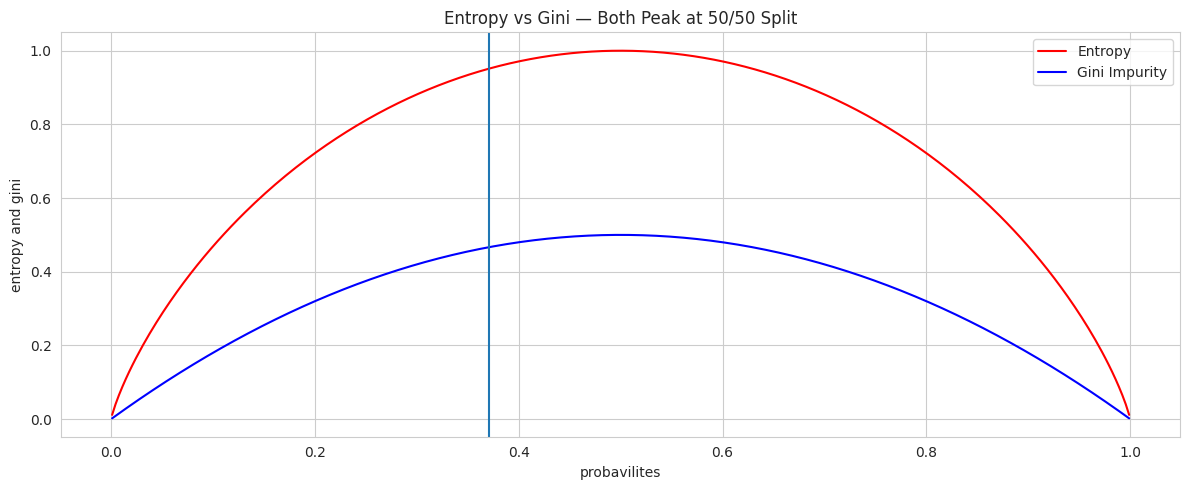

In [ ]:
# ============================================================
# TODO: Plot entropy and gini as functions of p (probability of class 1)
# ============================================================
p_range = np.linspace(0.001, 0.999, 300)

# TODO: build ent_vals = [entropy of a 2-class distribution with prob p, for each p in p_range]
#       You can compute this directly with the formula (not your entropy() function,
#       since that expects an array of actual data points, not a probability):
#       ent = -p*np.log2(p) - (1-p)*np.log2(1-p)
# TODO: build gin_vals = [1 - p**2 - (1-p)**2 for each p in p_range]

# TODO: plot both curves on the same axes (p_range on x, impurity on y)
# TODO: add a vertical line at your actual data's positive rate (df_long['class_target_1'].mean())
# TODO: label axes, add a legend, add a title like 'Entropy vs Gini — Both Peak at 50/50 Split'
# TODO: plt.tight_layout(); plt.show()

ent = [-p*(np.log2(p)) - (1-p)*(np.log2(1-p)) for p in p_range]
gin_vals = [1 - p**2 - (1-p)**2 for p in p_range]

# 2. Plot with explicit labels and colors
plt.plot(p_range, ent, color='r', label='Entropy')
plt.plot(p_range, gin_vals, color='b', label='Gini Impurity')

plt.axvline( x = df_long['class_target_1'].mean())

plt.title('Entropy vs Gini — Both Peak at 50/50 Split')
plt.xlabel('probavilites')
plt.ylabel('entropy and gini')

plt.legend()
plt.tight_layout()
plt.show()

---
# PART C — Bias-Variance Tradeoff (Tuesday)

### Concept: why does tree depth matter so much?

A Decision Tree with **no depth limit** will keep splitting until every leaf is perfectly pure — even if that means a leaf containing exactly one training example. On the data it was trained on, this tree scores close to 100% accuracy. But it hasn't learned a general pattern — it's memorised the noise specific to those exact training rows. Test it on new data and it falls apart. This failure mode is called **high variance**: small changes in which rows happened to be in the training set produce wildly different trees.

A tree with **`max_depth=1`** can only make a single split. If the real pattern in your data needs three or four conditions to describe (e.g. "ADX trending AND volume high AND aligned with the 4h trend"), a depth-1 tree can't represent that — it will be consistently, predictably wrong. This is **high bias**: the model is too simple to capture the real structure.

The sweet spot is somewhere in between, and you find it empirically: train the same tree architecture at several different depths, and at each depth measure **both** training accuracy (how well it fits the data it saw) and walk-forward CV accuracy (how well it generalises to data it didn't see). As depth increases, training accuracy always climbs toward 100%. CV accuracy climbs for a while too — then plateaus, then starts dropping as the tree starts memorising noise instead of learning signal. The gap between the two curves is itself informative: a small gap means the tree generalises well; a large gap means it's overfitting.

### Your task

Loop over depths `[1, 2, 3, 5, 10, None]`. At each depth, fit a tree on the *entire* `df_long` dataset to get training accuracy (this is deliberately the "memorisation ceiling" — not a fair test, just a reference point), and separately run `cv_no_scaling()` to get the honest walk-forward CV accuracy. Do this for both `class_target_1` and `class_target_2`.

In [50]:
# ============================================================
# TODO: Bias-variance experiment
# ============================================================
depths       = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]
depth_labels = ['1','2','3','4','5','6','7','8','9','10','None']
feat_set     = [f for f in FEATURES_COMBINED if f in df_long.columns]

bv_records = []

# TODO: write a nested loop:
for depth, label in zip(depths, depth_labels):
    for target in ['class_target_1', 'class_target_2', 'class_target_3']:
        dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced',
                                                   criterion='gini', random_state=42)
        cv_res = cv_no_scaling(dt, df_long, feat_set, target, n_splits=5)
# 3. Separately fit a clone of dt on the FULL df_long (no train/test split —
#              this deliberately overfits) to get train_acc:
        df_c = df_long[feat_set+[target]].replace([np.inf,-np.inf],np.nan).dropna()
        Xf, yf = df_c[feat_set].values, df_c[target].values
        dt_f = clone(dt); dt_f.fit(Xf, yf)
        train_acc = accuracy_score(yf, dt_f.predict(Xf))
        train_proba = dt_f.predict_proba(Xf)[:, 1]
        train_auc = roc_auc_score(yf, train_proba)
#           4. Append a dict to bv_records with: depth=label, target, train_acc,
        row_record = {
            'depth': label,
            'target': target,
            'train_acc': train_acc,
            'train_auc': train_auc,
            'cv_acc': cv_res['accuracy'][0],
            'cv_auc': cv_res['auc'][0],
            'cv_auc_std': cv_res['auc'][1],
            'cv_f1': cv_res['f1'][0],
            'gap': train_acc - cv_res['accuracy'][0]
        }
        bv_records.append(row_record)


# TODO: build bv_df = pd.DataFrame(bv_records) once the loop finishes
bv_df = pd.DataFrame(bv_records)
display(bv_df)


,depth,target,train_acc,train_auc,cv_acc,cv_auc,cv_auc_std,cv_f1,gap
0,1,class_target_1,0.580229,0.573824,0.582622,0.554781,0.012551,0.457907,-0.002393
1,1,class_target_2,0.657704,0.633470,0.641664,0.602114,0.022440,0.522040,0.016041
2,1,class_target_3,0.823175,0.812869,0.822391,0.796953,0.017831,0.746304,0.000783
3,2,class_target_1,0.580229,0.610264,0.535314,0.594994,0.007767,0.539678,0.044915
4,2,class_target_2,0.623577,0.674936,0.627664,0.649455,0.012178,0.537633,-0.004088
5,2,class_target_3,0.823175,0.872951,0.822094,0.851865,0.014270,0.750126,0.001080
6,3,class_target_1,0.611696,0.634063,0.619606,0.616056,0.014558,0.465665,-0.007911
7,3,class_target_2,0.666894,0.703344,0.657965,0.678693,0.008764,0.542796,0.008928
8,3,class_target_3,0.819338,0.895019,0.821797,0.881388,0.019384,0.759094,-0.002459
9,4,class_target_1,0.574474,0.653568,0.609543,0.626814,0.015570,0.502886,-0.035069


### Plot the bias-variance curve

One panel per target. Train accuracy and CV accuracy should both be visible, with the gap between them shaded — that visual gap IS the overfitting signal you're looking for.

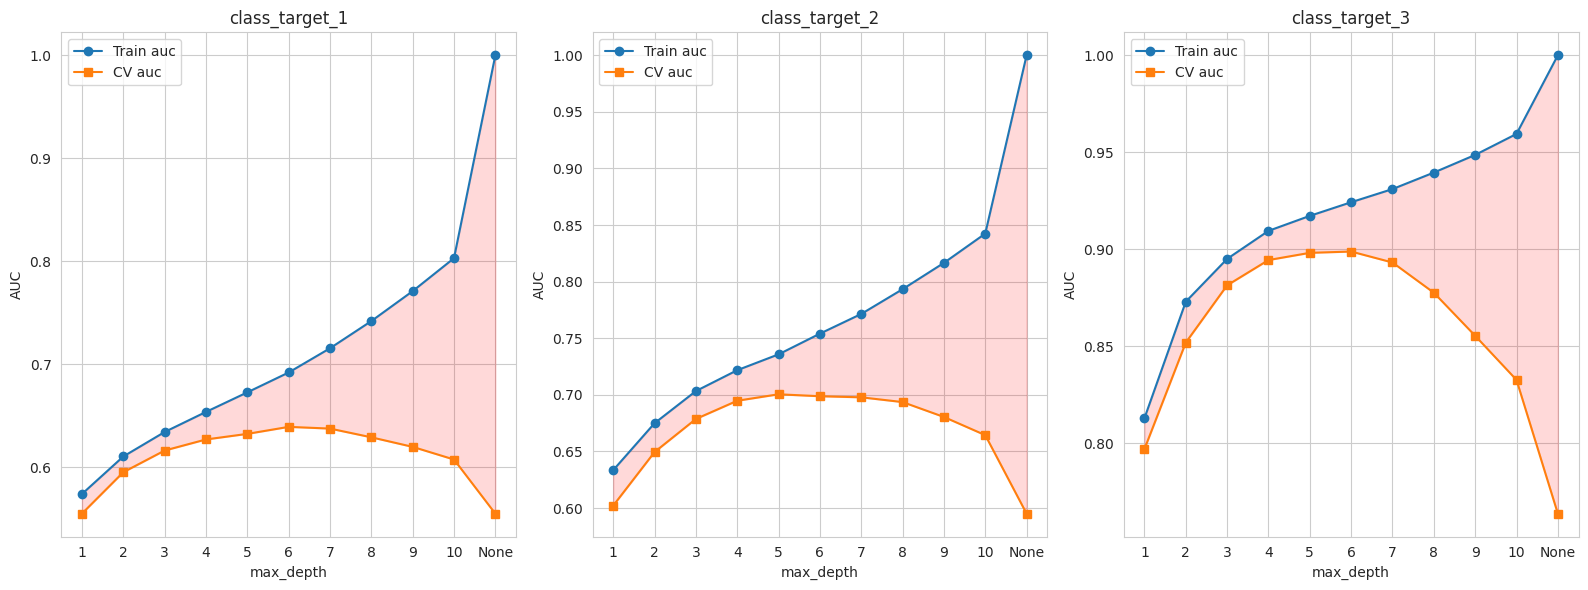

In [52]:
# ============================================================
# TODO: Plot train vs CV accuracy across depths, one panel per target
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
# TODO:
for ax, target in zip(axes, ['class_target_1', 'class_target_2', 'class_target_3']):
    sub = bv_df[bv_df['target'] == target]
    x = range(len(sub))
    ax.plot(x, sub['train_auc'], marker='o', label='Train auc')
    ax.plot(x, sub['cv_auc'], marker='s', label='CV auc')
    ax.fill_between(x, sub['cv_auc'], sub['train_auc'], alpha=0.15, color='red')
    ax.set_xticks(x); ax.set_xticklabels(sub['depth'])
    ax.set_xlabel('max_depth'); ax.set_ylabel('AUC'); ax.set_title(target); ax.legend()
plt.tight_layout()
plt.show()

# TODO: after plotting, for each target print which depth has the HIGHEST cv_auc,
#       and what the train-vs-cv gap is at that depth.
#       (Hint: sub.loc[sub['cv_auc'].idxmax()] gets you the best row)

# TODO answer in a comment:
#   - At what depth does the gap become large (say, > 0.05)? That's roughly
#     your overfitting boundary for this dataset.
#   - Does the optimal depth differ between class_target_1 and class_target_2?
#     If so, what might explain that — is one target "easier" to learn than the other?

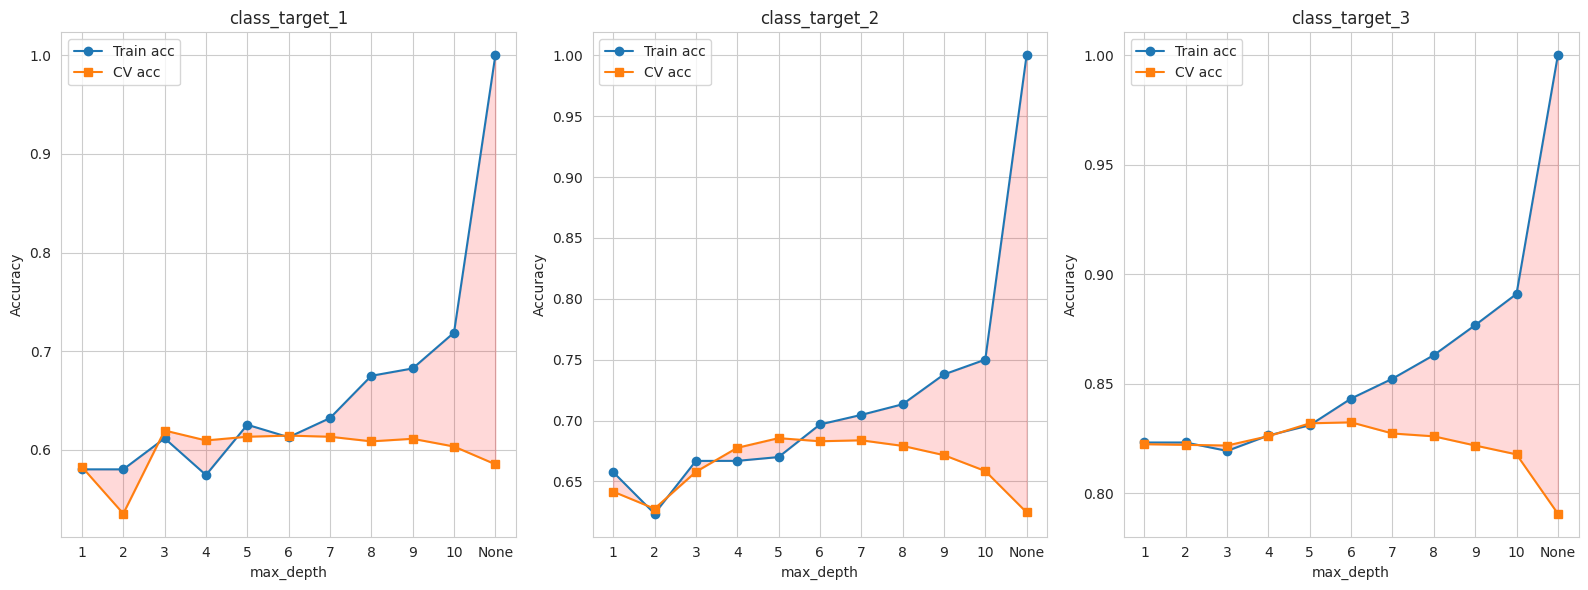

In [56]:
# ============================================================
# TODO: Plot train vs CV accuracy across depths, one panel per target
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
# TODO:
for ax, target in zip(axes, ['class_target_1', 'class_target_2','class_target_3']):
    sub = bv_df[bv_df['target'] == target]
    x = range(len(sub))
    ax.plot(x, sub['train_acc'], marker='o', label='Train acc')
    ax.plot(x, sub['cv_acc'], marker='s', label='CV acc')
    ax.fill_between(x, sub['cv_acc'], sub['train_acc'], alpha=0.15, color='red')
    ax.set_xticks(x); ax.set_xticklabels(sub['depth'])
    ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy'); ax.set_title(target); ax.legend()
plt.tight_layout()
plt.show()


In [53]:
# TODO: once you've identified the best depth from the plot above, store it here
# so later cells can reference it without you re-reading the chart each time.
# Use the depth with the highest cv_auc for each target. If 'None' wins but you'd
# rather force a finite depth (safer, since 'None' has the highest overfit risk),
# override manually.

BEST_DEPTH_CT1 = 6  # TODO: set to your chosen depth for class_target_1, e.g. 5
BEST_DEPTH_CT2 = 5  # TODO: set to your chosen depth for class_target_2
BEST_DEPTH_CT3 = 6
print(f'Best depth CT1: {BEST_DEPTH_CT1}')
print(f'Best depth CT2: {BEST_DEPTH_CT2}')

Best depth CT1: 6
Best depth CT2: 5


---
# PART D — Decision Tree Implementation + Visualisation (Wednesday)

### Concept

Now that you know roughly what depth avoids overfitting, train real trees and actually look inside them. `sklearn`'s `plot_tree()` draws the literal decision logic the algorithm learned — every node shows which feature it split on, the threshold, how many samples reached that node, and the class distribution at that point. At shallow depths (3–5), this is genuinely readable as a flowchart of trading rules, which is one of the main appeals of Decision Trees over something like Logistic Regression: you can show the tree to someone non-technical and they can follow the logic.

You'll also compare which features the tree thinks are important against which features Logistic Regression weighted most heavily. They measure fundamentally different things — a LogReg coefficient is the (linear) marginal contribution of a feature; a tree's **Mean Decrease in Impurity (MDI)** importance is how much that feature reduced impurity, summed across every split where it was used, anywhere in the tree. A feature can be useless to a linear model but extremely useful to a tree if its relationship to the target is non-linear (e.g. only matters above some threshold) — that disagreement is itself informative.

### Your task

Run a full CV sweep across feature sets and both directions, then visualise a depth-3 tree and pull its feature importances.

In [57]:
# ============================================================
# TODO: Decision Tree CV sweep, both directions, all 3 feature sets, both targets
# ============================================================
dt_records = []

# Loop over market directions
for direction_tuple in [('LONG', df_long, FEATURES_ALL, FEATURES_COMBINED, FEATURES_SELECTED_LONG),
                        ('SHORT', df_short, FEATURES_ALL, FEATURES_COMBINED, FEATURES_SELECTED_SHORT)]:

    direction_name = direction_tuple[0]
    df_dir = direction_tuple[1]

    # Map the feature groups
    feat_name_dict = {
        'Raw': direction_tuple[2],
        'Combined': direction_tuple[3],
        'Selected': direction_tuple[4]
    }

    # FIX: Use .items() to get both the label name and the feature list
    for feat_name, raw_feats in feat_name_dict.items():

        # FIX: Filter list to columns that actually exist in this dataframe
        feats = [f for f in raw_feats if f in df_dir.columns]

        # FIX: Added missing colon at the end of this loop statement
        for target, depth in [('class_target_1', BEST_DEPTH_CT1),
                              ('class_target_2', BEST_DEPTH_CT2),
                              ('class_target_3', BEST_DEPTH_CT3)]:

            # 1. Instantiate the optimal constrained tree
            dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced',
                                        criterion='gini', random_state=42)

            # 2. Run the cross-validation
            res = cv_no_scaling(dt, df_dir, feats, target, n_splits=5)

            # 3. Append clean record metrics (using index [0] to extract the mean)
            df_dict = {
                'direction': direction_name,
                'feature_set_name': feat_name,  # FIX: Save the name string, not the raw list
                'target': target,
                'depth': depth,
                'accuracy': res['accuracy'][0],
                'precision': res['precision'][0],
                'recall': res['recall'][0],     # Added per prompt specs
                'f1': res['f1'][0],             # Added per prompt specs
                'auc': res['auc'][0]
            }
            dt_records.append(df_dict)

            # 4. Clean, descriptive progress update
            print(f"Processed: {direction_name} | Features: {feat_name:10} | Target: {target} | CV AUC: {df_dict['auc']:.4f}")

# Build and display the master comparison DataFrame
dt_df = pd.DataFrame(dt_records)

Processed: LONG | Features: Raw        | Target: class_target_1 | CV AUC: 0.6208
Processed: LONG | Features: Raw        | Target: class_target_2 | CV AUC: 0.6872
Processed: LONG | Features: Raw        | Target: class_target_3 | CV AUC: 0.8933
Processed: LONG | Features: Combined   | Target: class_target_1 | CV AUC: 0.6390
Processed: LONG | Features: Combined   | Target: class_target_2 | CV AUC: 0.7005
Processed: LONG | Features: Combined   | Target: class_target_3 | CV AUC: 0.8988
Processed: LONG | Features: Selected   | Target: class_target_1 | CV AUC: 0.6219
Processed: LONG | Features: Selected   | Target: class_target_2 | CV AUC: 0.6983
Processed: LONG | Features: Selected   | Target: class_target_3 | CV AUC: 0.8895
Processed: SHORT | Features: Raw        | Target: class_target_1 | CV AUC: 0.6280
Processed: SHORT | Features: Raw        | Target: class_target_2 | CV AUC: 0.6912
Processed: SHORT | Features: Raw        | Target: class_target_3 | CV AUC: 0.9020
Processed: SHORT | Featur

### Visualise the tree

Fit one tree at `max_depth=3` on the full `df_long` + `class_target_1` (Combined features) and draw it with `plot_tree()`. Depth 3 is shallow enough to be fully readable on one figure.

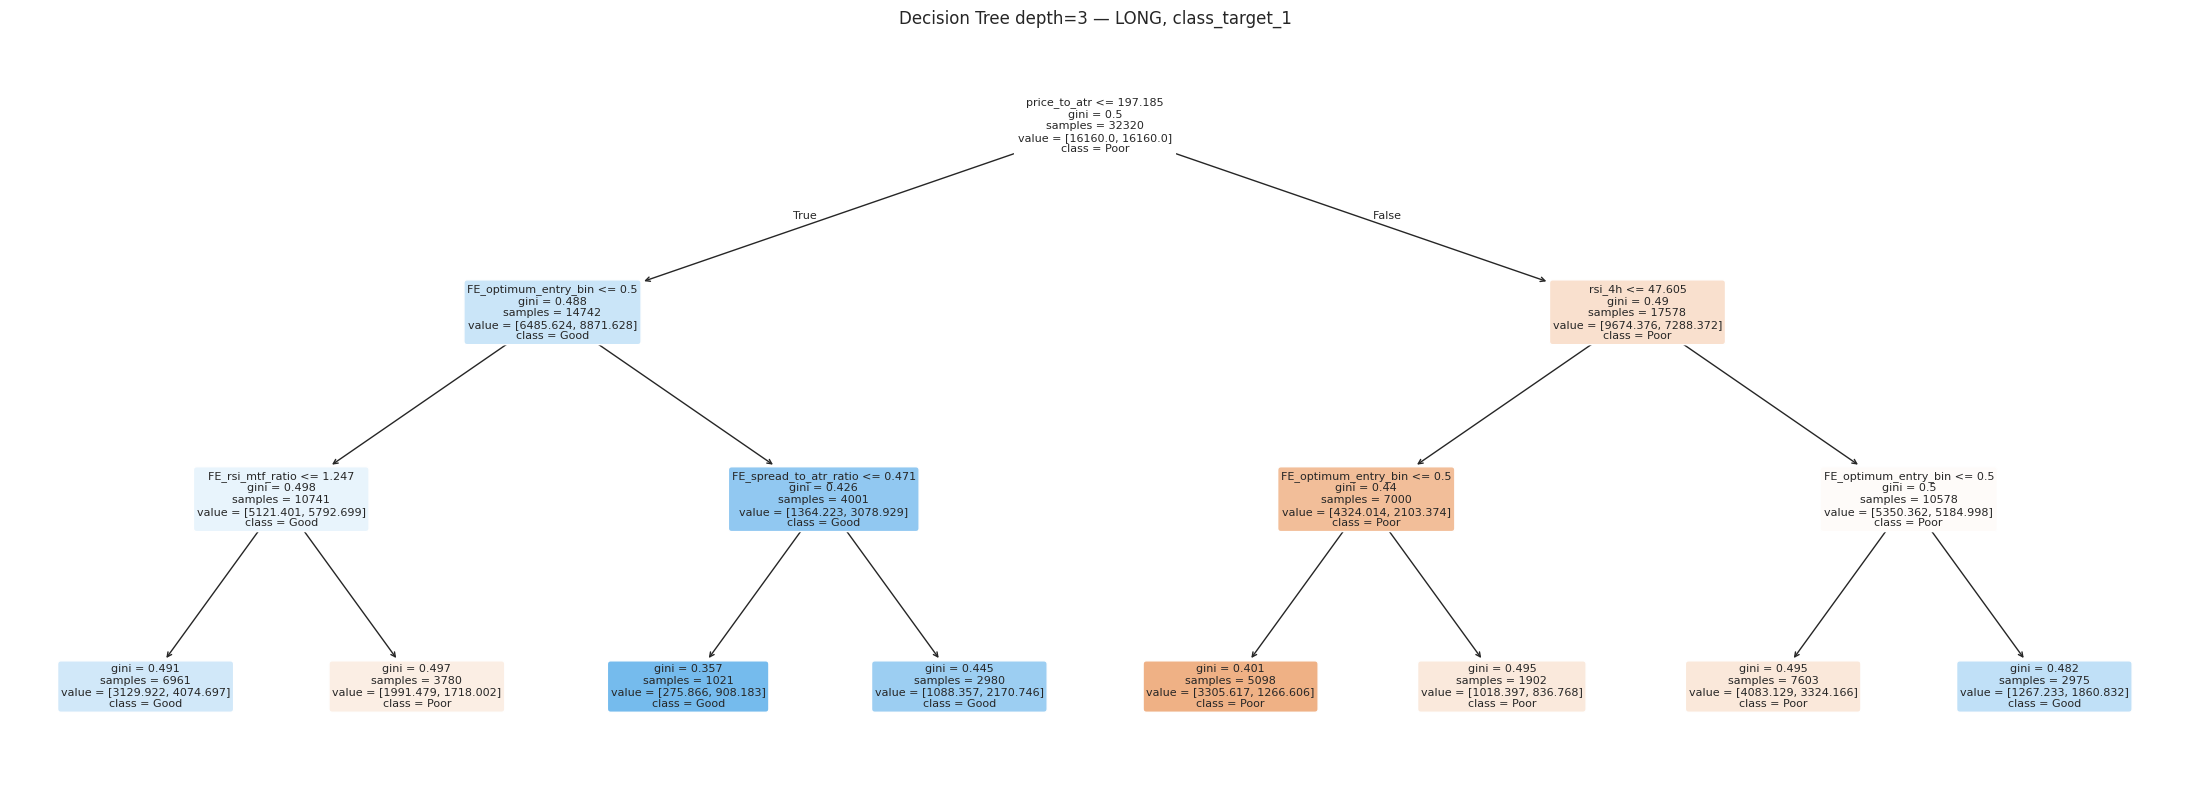

Root split: price_to_atr <= 197.1850


In [58]:
# ============================================================
# TODO: Visualise a depth-3 tree


# ============================================================

feat_viz = [f for f in FEATURES_COMBINED if f in df_long.columns]



# TODO: prepare Xv, yv:

#   df_v = df_long[feat_viz + ['class_target_1']].replace([np.inf,-np.inf], np.nan).dropna()

df_v = df_long[feat_viz + ['class_target_1']].replace([np.inf,-np.inf], np.nan).dropna()

#   Xv, yv = df_v[feat_viz].values, df_v['class_target_1'].values

Xv, yv = df_v[feat_viz].to_numpy(), df_v['class_target_1'].to_numpy()



# TODO: fit dt_viz = DecisionTreeClassifier(max_depth=3, class_weight='balanced',

#                                            criterion='gini', random_state=42)

#       on (Xv, yv)

dt_viz = DecisionTreeClassifier(max_depth=3, class_weight='balanced',

                                           criterion='gini', random_state=42)

dt_viz.fit(Xv,yv)

# TODO: plot it:

fig, ax = plt.subplots(figsize=(22, 8))

plot_tree(dt_viz, feature_names=feat_viz, class_names=['Poor','Good'],

          filled=True, rounded=True, fontsize=8, ax=ax)

ax.set_title('Decision Tree depth=3 — LONG, class_target_1')

plt.tight_layout(); plt.show()



# TODO: print the root node's feature and threshold:
root_feat = feat_viz[dt_viz.tree_.feature[0]]

root_thresh = dt_viz.tree_.threshold[0]

print(f'Root split: {root_feat} <= {root_thresh:.4f}')



# TODO answer in a comment: does the root split make trading sense to you?

#   Is it a feature you would have guessed mattered most

### Compare feature importance: tree (MDI) vs Logistic Regression (coefficients)

Fit a scaled LogReg on the same feature set, extract `|coefficient|` per feature, and compare its top-10 list against the tree's `feature_importances_` top-10.

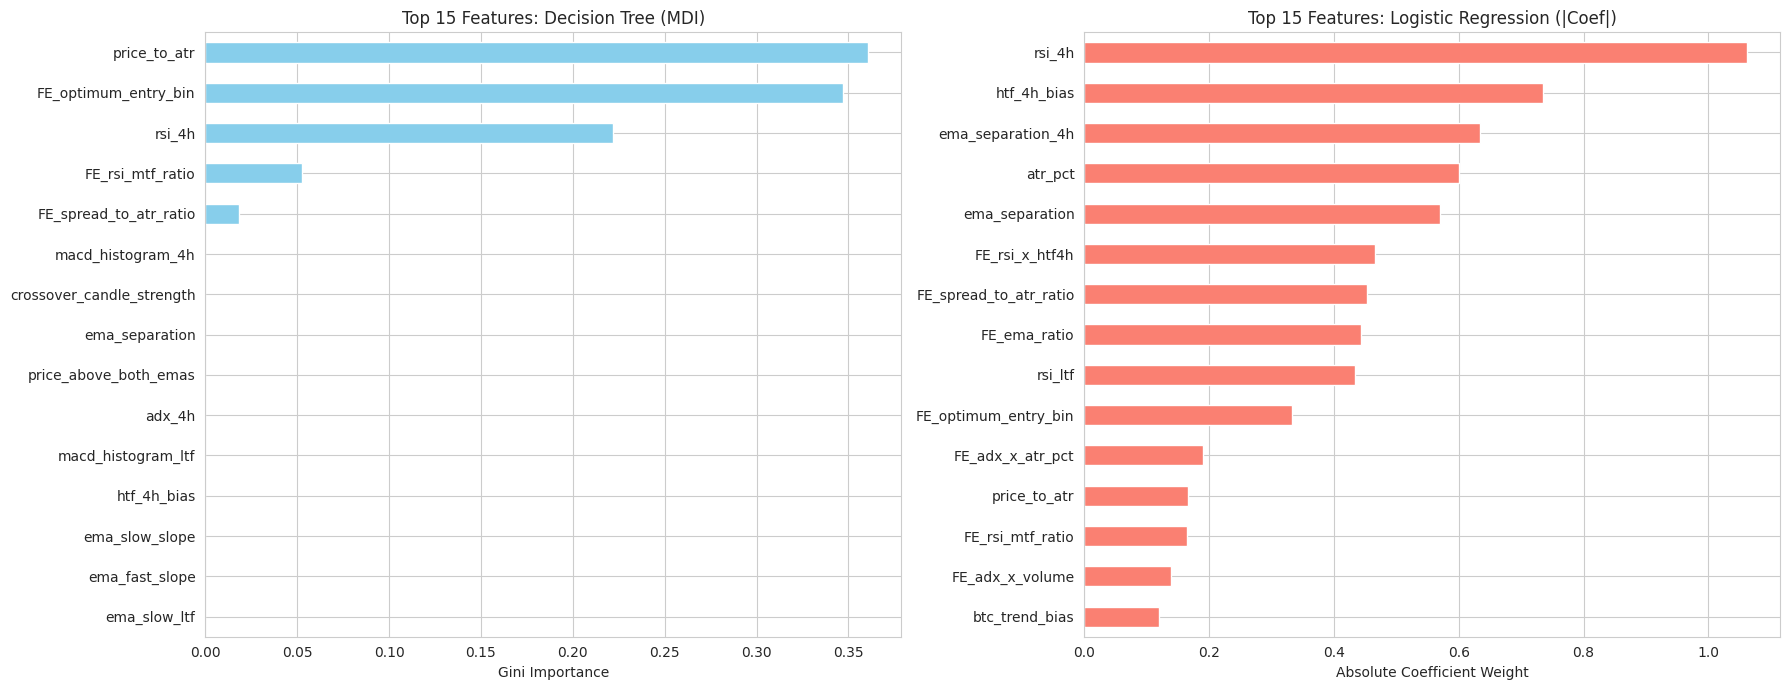

FEATURE SELECTION INSIGHTS (TOP 10)
🤝 Both Methods Agree On (4 features):
   ['rsi_4h', 'ema_separation', 'FE_optimum_entry_bin', 'FE_spread_to_atr_ratio']

🌲 Tree-Only Features (6 features - Potential Non-Linear Dynamics):
   ['price_above_both_emas', 'FE_rsi_mtf_ratio', 'ema_slow_slope', 'ema_slow_ltf', 'ema_fast_slope', 'price_to_atr']

📈 LogReg-Only Features (6 features - Linear/Additive Synergy):
   ['FE_rsi_x_htf4h', 'atr_pct', 'ema_separation_4h', 'htf_4h_bias', 'rsi_ltf', 'FE_ema_ratio']


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# TODO: Feature importance comparison
# ============================================================

# 1. Extract Tree MDI Importance Series from your already fitted dt_viz
imp_tree = pd.Series(dt_viz.feature_importances_, index=feat_viz).sort_values(ascending=False)

# 2. Fit a scaled LogReg on the same feat_viz / class_target_1 data
sc_lr = StandardScaler()
df_lr = df_long[feat_viz + ['class_target_1']].replace([np.inf, -np.inf], np.nan).dropna()

Xlr = sc_lr.fit_transform(df_lr[feat_viz].to_numpy())
ylr = df_lr['class_target_1'].to_numpy()

lr_v = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)
lr_v.fit(Xlr, ylr)

# Take absolute values of coefficients to measure raw magnitude of importance
imp_lr = pd.Series(np.abs(lr_v.coef_[0]), index=feat_viz).sort_values(ascending=False)

# 3. Plot top-15 of each side-by-side as horizontal bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left Subplot: Decision Tree MDI
imp_tree.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue', ax=ax1)
ax1.set_title('Top 15 Features: Decision Tree (MDI)')
ax1.set_xlabel('Gini Importance')

# Right Subplot: Logistic Regression Absolute Coefficients
imp_lr.head(15).sort_values(ascending=True).plot(kind='barh', color='salmon', ax=ax2)
ax2.set_title('Top 15 Features: Logistic Regression (|Coef|)')
ax2.set_xlabel('Absolute Coefficient Weight')

plt.tight_layout()
plt.show()

# 4. Compute and print set intersections for Top-10
tree_top_10 = set(imp_tree.head(10).index)
lr_top_10 = set(imp_lr.head(10).index)

agree = tree_top_10 & lr_top_10
tree_only = tree_top_10 - lr_top_10
lr_only = lr_top_10 - tree_top_10

print("=" * 60)
print("FEATURE SELECTION INSIGHTS (TOP 10)")
print("=" * 60)
print(f"🤝 Both Methods Agree On ({len(agree)} features):")
print(f"   {list(agree) if agree else 'None'}\n")

print(f"🌲 Tree-Only Features ({len(tree_only)} features - Potential Non-Linear Dynamics):")
print(f"   {list(tree_only) if tree_only else 'None'}\n")

print(f"📈 LogReg-Only Features ({len(lr_only)} features - Linear/Additive Synergy):")
print(f"   {list(lr_only) if lr_only else 'None'}")
print("=" * 60)

# TODO: plot top-15 of each side by side as horizontal bar charts (two subplots)

# TODO: compute set intersections:
#   agree = set(imp_tree.head(10).index) & set(imp_lr.head(10).index)
#   tree_only = set(imp_tree.head(10).index) - set(imp_lr.head(10).index)
#   print which features both methods agree on, and which are tree-only
#   (tree-only features suggest a non-linear relationship LogReg couldn't see)

---
# PART E — Pruning + Hyperparameter Tuning (Thursday)

### Concept

`max_depth` is a blunt instrument for controlling overfitting — it limits the tree uniformly everywhere, even in regions where a deeper split would genuinely help. sklearn gives you finer controls:

- **`min_samples_split`**: a node can only be split further if it contains at least this many samples. Prevents the tree from splitting a node of, say, 3 samples just because it happens to perfectly separate them — that "pattern" is statistical noise, not signal.
- **`min_samples_leaf`**: every resulting leaf must contain at least this many samples. Stops the tree from creating a leaf with 1-2 samples that's technically "pure" but meaningless.
- **`ccp_alpha`** (cost-complexity pruning): grows the tree fully first, then prunes branches back based on a cost-complexity tradeoff — a branch only survives if the impurity reduction it provides is worth more than `ccp_alpha` times the added complexity. Higher alpha = more aggressive pruning, smaller resulting tree.

### Your task

First, compute the cost-complexity pruning path to see what range of `ccp_alpha` is actually meaningful for your data (the range varies a lot by dataset — guessing blindly wastes a lot of grid search time). Then run a grid search over `max_depth × min_samples_split × min_samples_leaf × ccp_alpha`, verify the winning combination on SHORT signals too (not just LONG, which is what the search optimised on), and lock in your tuned tree.

In [ ]:
# ============================================================
# TODO: Cost-complexity pruning path
# ============================================================
feat_set = [f for f in FEATURES_COMBINED if f in df_long.columns]

# TODO: prepare Xp, yp from df_long[feat_set + ['class_target_1']] (drop NaN/inf, same pattern as before)

# TODO: fit an UNPRUNED tree (no max_depth limit) and call its cost_complexity_pruning_path:
#   dt_path = DecisionTreeClassifier(class_weight='balanced', random_state=42)
#   path = dt_path.cost_complexity_pruning_path(Xp, yp)
#   ccpas, impurs = path.ccp_alphas[:-1], path.impurities[:-1]   # drop the trivial final value

# TODO: plot ccpas (x) vs impurs (y) as a line — this shows how leaf impurity
#       changes as you prune more aggressively

# TODO: pick ~10 candidate alpha values spread across the range using
#       np.linspace(0, len(ccpas)-1, 10, dtype=int) as indices into ccpas
#       Print them so you can see the actual scale you're working with

In [ ]:
# ============================================================
# TODO: Grid search over max_depth x min_samples_split x min_samples_leaf x ccp_alpha
# ============================================================
# Suggested grid (adjust based on what your bias-variance plot suggested):
#   max_depth:         a few values around your BEST_DEPTH_CT1 (e.g. depth-1, depth, depth+2)
#   min_samples_split:  [10, 50, 100]
#   min_samples_leaf:   [5, 20, 50]
#   ccp_alpha:           a few of your candidate alphas from the cell above

# TODO: build the parameter grid as a dict, then use itertools.product(*grid.values())
#       to generate every combination

# TODO: for each combination:
#   1. Build a DecisionTreeClassifier with those exact params (plus class_weight='balanced',
#      criterion='gini', random_state=42)
#   2. Run cv_no_scaling() on df_long, feat_set, 'class_target_1'
#   3. Record the params + cv_auc + cv_f1 in a list of dicts

# TODO: build grid_df from that list, sort by cv_auc descending, print top 10

# TODO: extract the winning row's params into variables:
#   BEST_DEPTH_TUNED, BEST_MIN_SPLIT, BEST_MIN_LEAF, BEST_CCP_ALPHA

# TODO: IMPORTANT — verify the winning combo on df_short too, using the same params.
#       If SHORT's AUC with these params is much worse than LONG's, the tuning may
#       be overfit to LONG specifically — worth tuning SHORT separately in that case.

In [ ]:
# ============================================================
# TODO: Final tuned tree — evaluate on both directions, both targets
# ============================================================
# TODO: best_dt = DecisionTreeClassifier(max_depth=BEST_DEPTH_TUNED,
#           min_samples_split=BEST_MIN_SPLIT, min_samples_leaf=BEST_MIN_LEAF,
#           ccp_alpha=BEST_CCP_ALPHA, class_weight='balanced', criterion='gini', random_state=42)

# TODO: loop over [('LONG', df_long), ('SHORT', df_short)] and both targets,
#       run cv_no_scaling(), store results in a dict tuned_results['{direction}_{target}'],
#       and print_cv() each one

---
# PART F — Bagging Preview (Friday)

### Concept

A single Decision Tree, even a well-tuned one, is still high-variance compared to most other model types — train it on a slightly different sample of the same underlying data and you can get a noticeably different tree. **Bagging** (Bootstrap AGGregating) exploits this: train many trees, each on a random bootstrap sample (sampling with replacement) of the training data, then average their predicted probabilities. Each individual tree's errors are partly random and partly systematic; averaging cancels out the random part while the systematic signal survives. This is the direct mathematical predecessor to Random Forest, which you'll build next week — RF adds one more trick (randomising which features each split can consider) to decorrelate the trees even further.

### Your task

Wrap your tuned tree from Part E in a `BaggingClassifier` with 50 estimators and compare it directly. Then plot how AUC changes as you vary the number of trees from 1 to 100 — this tells you whether you're getting real value from ensembling or just burning compute past a point of diminishing returns.

In [ ]:
# ============================================================
# TODO: Bagging x50 vs single tuned tree
# ============================================================
# TODO: bagging_base = DecisionTreeClassifier(max_depth=BEST_DEPTH_TUNED,
#           min_samples_split=BEST_MIN_SPLIT, min_samples_leaf=BEST_MIN_LEAF,
#           class_weight='balanced', criterion='gini', random_state=42)

# TODO: bag_50 = BaggingClassifier(estimator=bagging_base, n_estimators=50,
#           max_samples=0.8, max_features=1.0, bootstrap=True, random_state=42, n_jobs=-1)
#       (max_samples=0.8 means each tree trains on a random 80% bootstrap sample)

# TODO: for direction, df_dir in [('LONG', df_long), ('SHORT', df_short)]:
#   1. feats = [f for f in FEATURES_COMBINED if f in df_dir.columns]
#   2. res_single = cv_no_scaling(best_dt, df_dir, feats, 'class_target_1')
#   3. res_bagging = cv_no_scaling(bag_50, df_dir, feats, 'class_target_1')
#   4. Print both AUCs and the delta between them
#   5. Store both results somewhere (e.g. a dict bag_vs_single[direction] = (res_single, res_bagging))
#      so you can reuse them in the comparison table later

# TODO answer in a comment:
#   - Large delta (say > 0.03 AUC) means your single tree had high variance — averaging helped a lot.
#   - Small delta means the tree was already fairly stable on its own.
#   - What does this predict about how much Random Forest will improve on this next week?

In [ ]:
# ============================================================
# TODO: Learning curve — AUC vs number of trees in the bagging ensemble
# ============================================================
n_range = [1, 5, 10, 20, 30, 50, 100]
feat_long = [f for f in FEATURES_COMBINED if f in df_long.columns]

# TODO: for each n in n_range:
#   1. Build a BaggingClassifier with n_estimators=n (same base estimator and other params as before)
#   2. Run cv_no_scaling() on df_long, feat_long, 'class_target_1'
#   3. Store {n, cv_auc} in a list

# TODO: build a DataFrame from that list and plot n_estimators (x) vs cv_auc (y) as a line
# TODO: add a horizontal dashed line at your single tree's AUC for reference

# TODO answer in a comment: at roughly what n does the curve flatten out?
#   Past that point you're spending compute for little to no AUC gain.

---
# PART G — Cumulative Comparison + Honest Record

This table and the record below pull together every result from the notebook. Fill them in with your actual numbers once you've completed Parts B–F — no placeholders, no approximations. This is the document Week 5's Random Forest needs to beat.

In [ ]:
# ============================================================
# TODO: Cumulative model comparison table
# ============================================================
# Build a list of dicts, one row per model/direction/target combination, with
# columns: Week, Model, Direction, Target, FeatureSet, AUC, F1.
# Pull the actual numbers from:
#   - baseline_results (Part A.8) for LogReg rows
#   - dt_df (Part D) for untuned tree rows
#   - tuned_results (Part E) for the tuned tree rows
#   - bag_vs_single (Part F) for the bagging rows
#
# TODO: comparison = [ ... ]
# TODO: comp_df = pd.DataFrame(comparison)
# TODO: print(comp_df.to_string(index=False))

In [ ]:
# ============================================================
# TODO: Week 4 Honest Record
# ============================================================
# Fill in every TODO below with your actual results. This isn't optional —
# the point of the honest record is having real numbers to compare against
# next week, not a vague memory of "the tree seemed better."

week4_record = """
=================================================================
             WEEK 4 PRODUCTION LOG — DECISION TREES
=================================================================

  DATASET
    Total rows: TODO | LONG: TODO | SHORT: TODO

  LOGREG BASELINE (65k+, Combined features)
    LONG  CT1: AUC=TODO  F1=TODO
    SHORT CT1: AUC=TODO  F1=TODO

  BIAS-VARIANCE
    Optimal depth CT1: TODO
    Optimal depth CT2: TODO
    Gap at optimal depth: TODO

  TUNED TREE (grid search)
    depth=TODO min_split=TODO min_leaf=TODO alpha=TODO
    LONG  CT1: AUC=TODO
    SHORT CT1: AUC=TODO

  BAGGING x50
    LONG  AUC=TODO (single tree: TODO)
    SHORT AUC=TODO (single tree: TODO)

  DECISION: Does the tuned tree beat the LogReg baseline?
    LONG:  Delta AUC = TODO
    SHORT: Delta AUC = TODO

  HONEST VERDICT
    Main insight this week:       TODO
    Root split that surprised me: TODO
    Expectation for Week 5 RF:    TODO
=================================================================
"""
print(week4_record)


             WEEK 4 PRODUCTION LOG — DECISION TREES

  DATASET
    Total rows: TODO | LONG: TODO | SHORT: TODO

  LOGREG BASELINE (65k+, Combined features)
    LONG  CT1: AUC=TODO  F1=TODO
    SHORT CT1: AUC=TODO  F1=TODO

  BIAS-VARIANCE
    Optimal depth CT1: TODO
    Optimal depth CT2: TODO
    Gap at optimal depth: TODO

  TUNED TREE (grid search)
    depth=TODO min_split=TODO min_leaf=TODO alpha=TODO
    LONG  CT1: AUC=TODO
    SHORT CT1: AUC=TODO

  BAGGING x50
    LONG  AUC=TODO (single tree: TODO)
    SHORT AUC=TODO (single tree: TODO)

  DECISION: Does the tuned tree beat the LogReg baseline?
    LONG:  Delta AUC = TODO
    SHORT: Delta AUC = TODO

  HONEST VERDICT
    Main insight this week:       TODO
    Root split that surprised me: TODO
    Expectation for Week 5 RF:    TODO

